# Singularity Analysis — NR cold start vs MLP warm start

In [9]:
import sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    !git clone https://github.com/max15189/InverseKinematics.git
    sys.path.insert(0, '/content/InverseKinematics')
    IN_COLAB = True
except ImportError:
    sys.path.insert(0, r"c:\Users\max\InverseKinematics")
    IN_COLAB = False

SAVE_DATA  = "/content/drive/MyDrive/inverse_kinematics/pos_rot_qinit" if IN_COLAB else "G:/My Drive/inverse_kinematics/pos_rot_qinit"
SAVE_MODEL = f"{SAVE_DATA}/mlp_ik.pt"

NR_MAX_ITER   = 50
NR_TOL        = 1e-3   # metres position tolerance
NR_DAMPING    = 0   # damped least-squares lambda
N_SAMPLES     = 3000   # configs to sample for manipulability mapping
K_LOW         = 10     # lowest-manipulability waypoints to build trajectory from
STEPS_PER_SEG = 10     # interpolation steps between consecutive waypoints

In [ ]:
!pip install modern-robotics -q

import numpy as np
import torch
import matplotlib.pyplot as plt
import modern_robotics as mr

from ik.kinematics.fk import _Slist_np as Slist, _M_HOME_np as M_home
from ik.data.dataset import IKDataset
from ik.model.mlp import MLP

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

## Load model + scalers

In [11]:
# Load train dataset only to get MinMax scalers (no test leakage)
train_ds = IKDataset("train", SAVE_DATA)
MinMax_X = train_ds.MinMax_X   # [min (15,), max (15,)]
MinMax_Y = train_ds.MinMax_Y   # [min (6,),  max (6,)]

model = MLP(input_dim=15).to(DEVICE)
model.load_state_dict(torch.load(SAVE_MODEL, map_location=DEVICE))
model.eval()
print("model loaded")

model loaded


## Helpers — Jacobian, NR, MLP warm start

In [ ]:
def manipulability(q):
    """Yoshikawa manipulability index using mr.JacobianSpace. Zero at singularity."""
    J = mr.JacobianSpace(Slist, q)
    return np.sqrt(max(np.linalg.det(J @ J.T), 0.0))


def IKinSpace_with_iters(Slist, M, T, thetalist0, eomg, ev):
    """NR IK via modern_robotics (no damping). Returns (q, converged, iterations)."""
    thetalist     = np.array(thetalist0).copy()
    i             = 0
    maxiterations = NR_MAX_ITER
    Tsb = mr.FKinSpace(M, Slist, thetalist)
    Vs  = np.dot(mr.Adjoint(Tsb), mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
    err = np.linalg.norm(Vs[:3]) > eomg or np.linalg.norm(Vs[3:]) > ev
    while err and i < maxiterations:
        thetalist = thetalist + np.dot(np.linalg.pinv(mr.JacobianSpace(Slist, thetalist)), Vs)
        i  += 1
        Tsb = mr.FKinSpace(M, Slist, thetalist)
        Vs  = np.dot(mr.Adjoint(Tsb), mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
        err = np.linalg.norm(Vs[:3]) > eomg or np.linalg.norm(Vs[3:]) > ev
    return thetalist, not err, i


def mlp_predict(q_current, T_target, model, MinMax_X, MinMax_Y, device):
    """One-shot MLP prediction: [R6(6), P(3), q_current(6)] → q_target (6)."""
    R6     = T_target[:2, :3].flatten().astype(np.float32)
    P      = T_target[:3, 3].astype(np.float32)
    x      = np.concatenate([R6, P, q_current.astype(np.float32)])
    x_norm = (x - MinMax_X[0]) / (MinMax_X[1] - MinMax_X[0])
    x_norm = (x_norm * 2) - 1
    with torch.no_grad():
        x_t = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(device)
        y_t = model(x_t).squeeze(0).cpu().numpy()
    return (y_t + 1) / 2 * (MinMax_Y[1] - MinMax_Y[0]) + MinMax_Y[0]

## Map singularities — manipulability distribution

min:    0.0000
median: 0.0068
max:    0.0422
near-singular (< 0.01): 1847 / 3000


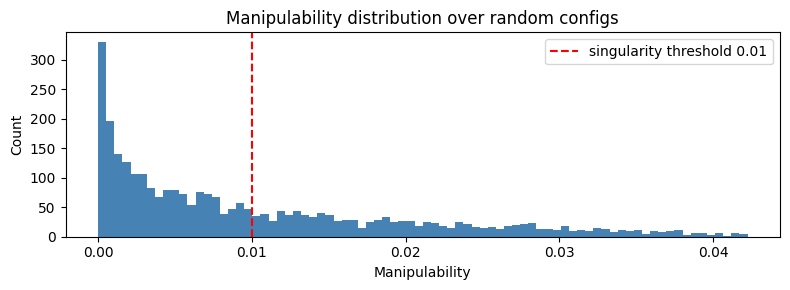

In [13]:
from ik.kinematics.fk import JOINT_LIMITS

np.random.seed(42)
q_samples  = np.random.uniform(JOINT_LIMITS[:, 0], JOINT_LIMITS[:, 1], size=(N_SAMPLES, 6))
manip_vals = np.array([manipulability(q) for q in q_samples])

print(f"min:    {manip_vals.min():.4f}")
print(f"median: {np.median(manip_vals):.4f}")
print(f"max:    {manip_vals.max():.4f}")
print(f"near-singular (< 0.01): {(manip_vals < 0.01).sum()} / {N_SAMPLES}")

plt.figure(figsize=(8, 3))
plt.hist(manip_vals, bins=80, color="steelblue", edgecolor="none")
plt.axvline(0.01, color="red", linestyle="--", label="singularity threshold 0.01")
plt.xlabel("Manipulability"); plt.ylabel("Count")
plt.title("Manipulability distribution over random configs")
plt.legend(); plt.tight_layout(); plt.show()

## Trajectory through lowest-manipulability configs

Pick the `K_LOW` configs with lowest manipulability, order them by nearest-neighbour in joint space to keep the trajectory smooth, then interpolate between consecutive waypoints.

Manipulability of selected waypoints:
  0: 0.00000
  1: 0.00000
  2: 0.00000
  3: 0.00000
  4: 0.00001
  5: 0.00001
  6: 0.00001
  7: 0.00001
  8: 0.00001
  9: 0.00001

Trajectory: 90 steps | min manipulability: 0.00000 at step 0


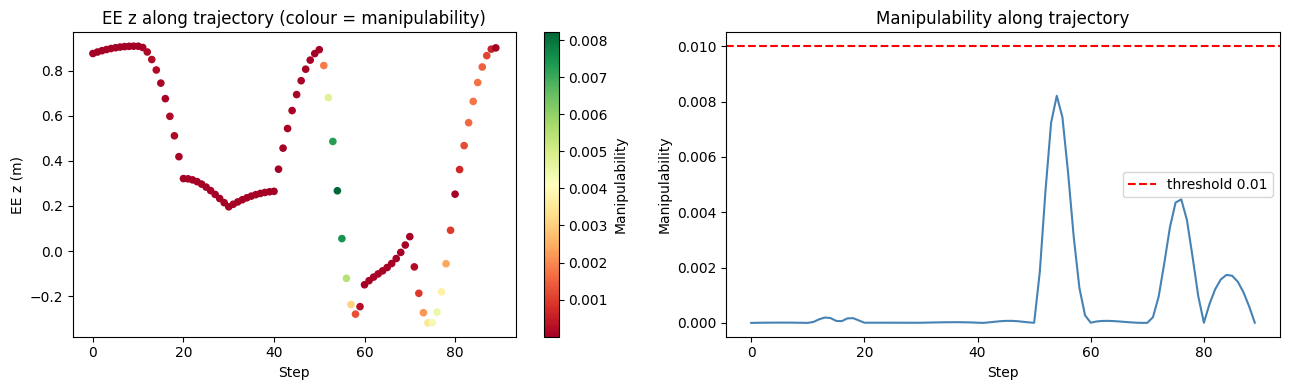

In [14]:
# --- K_LOW lowest-manipulability configs ---
idx_low   = np.argsort(manip_vals)[:K_LOW]
q_low     = q_samples[idx_low]
m_low     = manip_vals[idx_low]
print("Manipulability of selected waypoints:")
for i, m in enumerate(m_low):
    print(f"  {i}: {m:.5f}")

# --- nearest-neighbour ordering in joint space for a smooth path ---
order     = [0]
remaining = list(range(1, K_LOW))
while remaining:
    last    = order[-1]
    dists   = [np.linalg.norm(q_low[last] - q_low[r]) for r in remaining]
    nearest = remaining[np.argmin(dists)]
    order.append(nearest)
    remaining.remove(nearest)
q_ordered = q_low[order]

# --- interpolate between consecutive waypoints ---
q_traj, T_traj, m_traj = [], [], []
for i in range(len(q_ordered) - 1):
    for t in np.linspace(0, 1, STEPS_PER_SEG, endpoint=(i == len(q_ordered) - 2)):
        q = q_ordered[i] + t * (q_ordered[i + 1] - q_ordered[i])
        q_traj.append(q)
        T_traj.append(FK(q))
        m_traj.append(manipulability(q))

q_traj = np.array(q_traj)
T_traj = np.array(T_traj)
m_traj = np.array(m_traj)
print(f"\nTrajectory: {len(q_traj)} steps | min manipulability: {m_traj.min():.5f} at step {m_traj.argmin()}")

# --- visualise ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pos = T_traj[:, :3, 3]
sc  = axes[0].scatter(np.arange(len(q_traj)), pos[:, 2], c=m_traj, cmap="RdYlGn", s=20)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("EE z (m)")
axes[0].set_title("EE z along trajectory (colour = manipulability)")
plt.colorbar(sc, ax=axes[0], label="Manipulability")

axes[1].plot(m_traj, color="steelblue")
axes[1].axhline(0.01, color="red", linestyle="--", label="threshold 0.01")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Manipulability")
axes[1].set_title("Manipulability along trajectory"); axes[1].legend()
plt.tight_layout(); plt.show()

## Run comparison — NR cold start vs NR MLP warm start

In [ ]:
cold_iters, cold_conv, cold_pos_err = [], [], []
warm_iters, warm_conv, warm_pos_err = [], [], []

q_cold = q_traj[0].copy()
q_warm = q_traj[0].copy()

for T_target in T_traj:
    # --- cold start: NR from previous solution ---
    q_sol_cold, conv_cold, it_cold = IKinSpace_with_iters(Slist, M_home, T_target, q_cold, 0.01, NR_TOL)
    err_cold = np.linalg.norm(T_target[:3, 3] - mr.FKinSpace(M_home, Slist, q_sol_cold)[:3, 3])

    # --- warm start: MLP prediction → NR ---
    q_mlp = mlp_predict(q_warm, T_target, model, MinMax_X, MinMax_Y, DEVICE)
    q_sol_warm, conv_warm, it_warm = IKinSpace_with_iters(Slist, M_home, T_target, q_mlp, 0.01, NR_TOL)
    err_warm = np.linalg.norm(T_target[:3, 3] - mr.FKinSpace(M_home, Slist, q_sol_warm)[:3, 3])

    cold_iters.append(it_cold);  cold_conv.append(conv_cold);  cold_pos_err.append(err_cold)
    warm_iters.append(it_warm);  warm_conv.append(conv_warm);  warm_pos_err.append(err_warm)

    q_cold = q_sol_cold
    q_warm = q_sol_warm

cold_iters  = np.array(cold_iters);  cold_pos_err = np.array(cold_pos_err)
warm_iters  = np.array(warm_iters);  warm_pos_err = np.array(warm_pos_err)

print(f"{'':25s} {'cold':>10} {'warm':>10}")
print(f"{'mean iterations':25s} {cold_iters.mean():>10.2f} {warm_iters.mean():>10.2f}")
print(f"{'converged (%)':25s} {100*np.mean(cold_conv):>10.1f} {100*np.mean(warm_conv):>10.1f}")
print(f"{'mean pos error (m)':25s} {cold_pos_err.mean():>10.4f} {warm_pos_err.mean():>10.4f}")
print(f"{'max pos error (m)':25s} {cold_pos_err.max():>10.4f} {warm_pos_err.max():>10.4f}")

## Visualise results

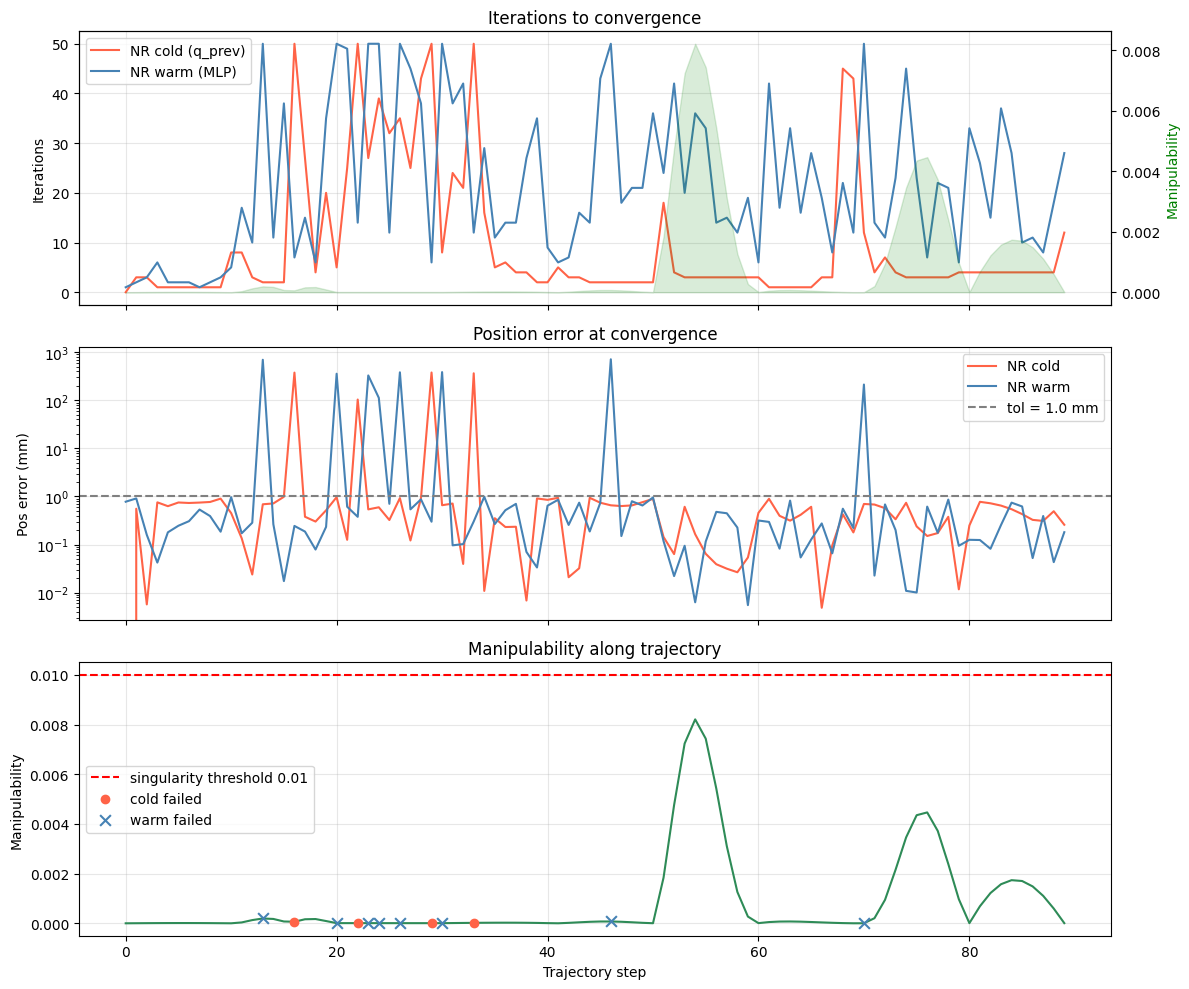

In [17]:
steps = np.arange(len(q_traj))
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
ax.plot(steps, cold_iters, label="NR cold (q_prev)", color="tomato",    linewidth=1.5)
ax.plot(steps, warm_iters, label="NR warm (MLP)",    color="steelblue", linewidth=1.5)
ax2 = ax.twinx()
ax2.fill_between(steps, m_traj, alpha=0.15, color="green")
ax2.set_ylabel("Manipulability", color="green")
ax.set_ylabel("Iterations"); ax.set_title("Iterations to convergence")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(steps, cold_pos_err * 1000, label="NR cold", color="tomato",    linewidth=1.5)
ax.semilogy(steps, warm_pos_err * 1000, label="NR warm", color="steelblue", linewidth=1.5)
ax.axhline(NR_TOL * 1000, color="gray", linestyle="--", label=f"tol = {NR_TOL*1000:.1f} mm")
ax.set_ylabel("Pos error (mm)"); ax.set_title("Position error at convergence")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(steps, m_traj, color="seagreen", linewidth=1.5)
ax.axhline(0.01, color="red", linestyle="--", label="singularity threshold 0.01")
cold_fail = np.where(~np.array(cold_conv))[0]
warm_fail = np.where(~np.array(warm_conv))[0]
if len(cold_fail):
    ax.scatter(cold_fail, m_traj[cold_fail], color="tomato",    zorder=5, label="cold failed")
if len(warm_fail):
    ax.scatter(warm_fail, m_traj[warm_fail], color="steelblue", zorder=5, label="warm failed", marker="x", s=60)
ax.set_xlabel("Trajectory step"); ax.set_ylabel("Manipulability")
ax.set_title("Manipulability along trajectory"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()